# Signal Processing and Learning
## HW3 — Trading and Portfolio Optimization

**Amirali Askari - Zahra Nazar Zadeh Attar - Kasra Alizadeh**




This notebook implements **HW-compliant** trading simulations using:
- **Linear regression** to predict **same-day close** from **information available at market open**.
- **Logistic regression** to predict **buy/sell probability** for same-day intraday return.

Key rules enforced:
- Targets use **same-day intraday outcome** (Close\_t vs Open\_t), **no next-day shift**.
- Features use only **information known at (or before) the open of day _t_** (lags, no leakage).
- Train on **2018-01-01 → 2018-06-30**, test on **2018-07-01 → 2018-12-31**.
- Portfolio backtest supports:
  1) **Fully invested daily weights** (continuous allocation)
  2) Optional **integer shares** using opening prices (closer to HW wording)

> Dataset: `OriginalCSV.zip` with one CSV per ticker, containing Date, Open, Close, Volume.


In [1]:
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd

# Reproducibility
np.random.seed(0)

# ---- Paths ----
ZIP_PATH = Path("OriginalCSV.zip")
EXTRACT_DIR = Path("OriginalCSV_extracted")
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Dataset tickers (must match extracted CSV filenames) ----
TICKERS = [
    "AAPL",
    "ADBE",
    "AMD",
    "AMZN",
    "AVGO",
    "FB",
    "GOOGL",
    "MSFT",
    "QCOM",
    "TWTR",
]

# ---- Train / Validation / Test split ----
TRAIN_START, TRAIN_END = "2018-01-01", "2018-05-31"
VAL_START,   VAL_END   = "2018-06-01", "2018-06-30"
TEST_START,  TEST_END  = "2018-07-01", "2018-12-31"

In [2]:
# Extract zip (idempotent)
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

# List extracted files
sorted([p.name for p in EXTRACT_DIR.glob("*.csv")])[:15], len(list(EXTRACT_DIR.glob("*.csv")))


(['AAPL.csv',
  'ADBE.csv',
  'AMD.csv',
  'AMZN.csv',
  'AVGO.csv',
  'FB.csv',
  'GOOGL.csv',
  'MSFT.csv',
  'QCOM.csv',
  'TWTR.csv'],
 10)

In [3]:
def _read_one_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Normalize columns
    df.columns = [c.strip().title() for c in df.columns]
    if "Date" not in df.columns:
        raise ValueError(f"'Date' column not found in {path.name}. Columns: {df.columns.tolist()}")
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").set_index("Date")
    # Keep needed columns
    needed = ["Open","Close","Volume"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing {missing} in {path.name}. Columns: {df.columns.tolist()}")
    return df[needed].copy()

def load_panel(extract_dir: Path, tickers: list[str]) -> dict[str, pd.DataFrame]:
    out = {}
    for t in tickers:
        # Try common filename patterns
        candidates = list(extract_dir.glob(f"*{t}*.csv"))
        if not candidates:
            raise FileNotFoundError(f"No CSV found for ticker '{t}' in {extract_dir}")
        # Prefer exact match if present
        exact = [p for p in candidates if p.stem.upper() == t]
        path = exact[0] if exact else sorted(candidates)[0]
        out[t] = _read_one_csv(path)
    return out

panel = load_panel(EXTRACT_DIR, TICKERS)

# Build aligned DataFrames (intersection of dates across all tickers)
dates = None
for t, df in panel.items():
    dates = df.index if dates is None else dates.intersection(df.index)
dates = dates.sort_values()

Open  = pd.DataFrame({t: panel[t].loc[dates, "Open"] for t in TICKERS}, index=dates)
Close = pd.DataFrame({t: panel[t].loc[dates, "Close"] for t in TICKERS}, index=dates)
Vol   = pd.DataFrame({t: panel[t].loc[dates, "Volume"] for t in TICKERS}, index=dates)

# Same-day intraday return (realized by close)
R = (Close - Open) / Open

Open.shape, Close.shape, Vol.shape, R.shape


((1325, 10), (1325, 10), (1325, 10), (1325, 10))

## Quick sanity checks

In [4]:
display(Open.head())
display(Close.head())
display(Vol.head())
display(R.describe().T[["mean","std","min","max"]].sort_values("std", ascending=False))


,AAPL,ADBE,AMD,AMZN,AVGO,FB,GOOGL,MSFT,QCOM,TWTR
Date,,,,,,,,,,
2013-12-31,79.167145,59.599998,3.87,394.579987,52.869999,54.119999,556.676697,37.400002,73.760002,62.360001
2014-01-02,79.382858,59.060001,3.85,398.799988,52.849998,54.830002,558.288269,37.349998,73.610001,65.000000
2014-01-03,78.980003,59.189999,3.98,398.290009,52.450001,55.020000,558.058044,37.200001,73.330002,69.000000
2014-01-06,76.778572,58.060001,4.01,395.850006,52.799999,54.419998,557.062073,36.849998,73.080002,64.830002
2014-01-07,77.760002,58.259998,4.19,395.040009,52.820000,57.700001,563.063049,36.330002,72.800003,67.669998


,AAPL,ADBE,AMD,AMZN,AVGO,FB,GOOGL,MSFT,QCOM,TWTR
Date,,,,,,,,,,
2013-12-31,80.145714,59.880001,3.87,398.790009,52.880001,54.650002,560.915894,37.410000,74.250000,63.650002
2014-01-02,79.018570,59.290001,3.95,397.970001,52.650002,54.709999,557.117126,37.160000,73.320000,67.500000
2014-01-03,77.282860,59.160000,4.00,396.440002,52.849998,54.560001,553.053040,36.910000,72.889999,69.000000
2014-01-06,77.704285,58.119999,4.13,393.630005,52.490002,57.200001,559.219238,36.130001,72.699997,66.290001
2014-01-07,77.148575,58.970001,4.18,398.029999,52.990002,57.919998,570.000000,36.410000,73.239998,61.459999


,AAPL,ADBE,AMD,AMZN,AVGO,FB,GOOGL,MSFT,QCOM,TWTR
Date,,,,,,,,,,
2013-12-31,55771100,1391300,12347800,1996500,865500,43076200,2713000,17503500,5725100,27814600
2014-01-02,58671200,2745900,20548400,2137800,1453700,43195500,3639100,30632200,10110200,29246400
2014-01-03,98116900,1589000,22887200,2210200,1166100,38246200,3330000,31134800,7970400,33207200
2014-01-06,103152700,3753600,42398300,3170600,1263400,68852600,3535000,43603700,7696200,27243700
2014-01-07,79302300,2963600,42932100,1916000,1335900,77207400,5100000,35802800,5902700,31748400


,mean,std,min,max
AMD,0.000742,0.031551,-0.124676,0.250784
TWTR,-0.000422,0.026066,-0.189609,0.102713
AVGO,0.000392,0.016483,-0.082186,0.087546
FB,0.000383,0.014917,-0.067192,0.065689
AMZN,-0.000148,0.014891,-0.085615,0.074520
ADBE,0.000681,0.014141,-0.074989,0.079504
QCOM,0.000054,0.013436,-0.099771,0.128744
AAPL,0.000346,0.012056,-0.066331,0.086961
GOOGL,-0.000248,0.011948,-0.057558,0.049960
MSFT,0.000484,0.011631,-0.057615,0.056969


## Feature engineering (HW-compliant, no leakage)

At day **t (open)** we know:
- today's **Open\_t**
- all **past** closes, volumes, returns up to day **t-1**

We build features for each ticker using only lagged information.


In [5]:
def make_features(
    Open: pd.DataFrame,
    Close: pd.DataFrame,
    Vol: pd.DataFrame,
    lags: int = 3
) -> dict[str, pd.DataFrame]:
    """Feature engineering.
    All features must be known at market open on day t.
    We therefore use ONLY lagged information (shift >= 1).
    """
    feats: dict[str, pd.DataFrame] = {}

    # Same-day intraday return (used ONLY to create *lagged* predictors)
    R = (Close - Open) / Open

    for tkr in Open.columns:
        df = pd.DataFrame(index=Open.index)

        # --- Core lagged predictors ---
        # Recent intraday returns (very short memory works best for intraday)
        for k in range(1, lags + 1):
            df[f"ret_l{k}"] = R[tkr].shift(k)

        # Volume surprise (yesterday volume vs its recent average)
        df["vol_l1"] = Vol[tkr].shift(1)
        df["dvol_l1"] = Vol[tkr].shift(1) / (Vol[tkr].shift(2) + 1e-8) - 1.0
        df["vol_ratio"] = Vol[tkr].shift(1) / (Vol[tkr].shift(1).rolling(5).mean() + 1e-8)

        # Overnight gap: today's open vs yesterday close
        df["gap"] = (Open[tkr] - Close[tkr].shift(1)) / Close[tkr].shift(1)

        # Previous-day intraday move (mean-reversion / continuation proxy)
        df["prev_intraday"] = (Close[tkr].shift(1) - Open[tkr].shift(1)) / Open[tkr].shift(1)

        # Rolling volatility of intraday returns (risk regime), strictly lagged
        df["vol_5"] = R[tkr].shift(1).rolling(5).std()

        # ---------- Experienced quant features (all open-known / lagged) ----------
        # Gap momentum
        df["gap_ma3"] = df["gap"].rolling(3).mean()
        df["gap_ma10"] = df["gap"].rolling(10).mean()

        # Overnight returns (today open vs past closes)
        df["overnight_ret1"] = (Open[tkr] / Close[tkr].shift(1) - 1.0)
        df["overnight_ret5"] = (Open[tkr] / Close[tkr].shift(5) - 1.0)

        # Intraday momentum (yesterday and rolling means)
        intr = R[tkr]
        df["intraday_1"] = intr.shift(1)
        df["intraday_3"] = intr.shift(1).rolling(3).mean()
        df["intraday_5"] = intr.shift(1).rolling(5).mean()

        # Volatility regime
        df["vol_10"] = intr.shift(1).rolling(10).std()
        df["vol_ratio_5_10"] = df["vol_5"] / (df["vol_10"] + 1e-12)

        # Abnormal volume (z-score + ratio to 20d mean), lagged
        v1 = Vol[tkr].shift(1)
        v20 = Vol[tkr].shift(1).rolling(20).mean()
        v20s = Vol[tkr].shift(1).rolling(20).std()
        df["vol_z20"] = (v1 - v20) / (v20s + 1e-12)
        df["vol_ratio20"] = v1 / (v20 + 1e-12)

        # Trend proxy from past closes (MA crossover)
        c1 = Close[tkr].shift(1)
        ma5 = c1.rolling(5).mean()
        ma10 = c1.rolling(10).mean()
        df["ma_diff_5_10"] = (ma5 - ma10) / (ma10 + 1e-12)

        df = df.replace([np.inf, -np.inf], np.nan)
        feats[tkr] = df.dropna()

    return feats


## Models

In [6]:
# Build targets and feature dictionary (per ticker)

# Target for linear regression: same-day closing price
Y_close = Close.copy()

# Feature dictionary (per ticker). Each FEATS[tkr] is a DataFrame of lagged features with NaNs removed.
FEATS = make_features(Open, Close, Vol, lags=5)

# Quick sanity check
list(FEATS.keys()), FEATS[TICKERS[0]].shape


(['AAPL',
  'ADBE',
  'AMD',
  'AMZN',
  'AVGO',
  'FB',
  'GOOGL',
  'MSFT',
  'QCOM',
  'TWTR'],
 (1305, 23))

In [7]:
FEATS[TICKERS[0]].columns

Index(['ret_l1', 'ret_l2', 'ret_l3', 'ret_l4', 'ret_l5', 'vol_l1', 'dvol_l1',
       'vol_ratio', 'gap', 'prev_intraday', 'vol_5', 'gap_ma3', 'gap_ma10',
       'overnight_ret1', 'overnight_ret5', 'intraday_1', 'intraday_3',
       'intraday_5', 'vol_10', 'vol_ratio_5_10', 'vol_z20', 'vol_ratio20',
       'ma_diff_5_10'],
      dtype='object')

In [8]:
FEATS[TICKERS[0]].head()

,ret_l1,ret_l2,ret_l3,ret_l4,ret_l5,vol_l1,dvol_l1,vol_ratio,gap,prev_intraday,...,overnight_ret1,overnight_ret5,intraday_1,intraday_3,intraday_5,vol_10,vol_ratio_5_10,vol_z20,vol_ratio20,ma_diff_5_10
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-30,-0.006350,-0.004442,0.000782,-0.014314,0.011347,125702500.0,-0.528110,0.850546,0.003575,-0.006350,...,0.003575,-0.096444,-0.006350,-0.003337,-0.002596,0.010753,0.883006,0.608429,1.281740,-0.017155
2014-01-31,-0.005492,-0.006350,-0.004442,0.000782,-0.014314,169625400.0,0.349419,1.049965,-0.009204,-0.005492,...,-0.009204,-0.093193,-0.005492,-0.005428,-0.005963,0.010437,0.520203,1.403031,1.634716,-0.027651
2014-02-03,0.010945,-0.005492,-0.006350,-0.004442,0.000782,116199300.0,-0.314965,0.711458,0.004015,0.010945,...,0.004015,-0.086994,0.010945,-0.000299,-0.000911,0.011257,0.638255,0.208783,1.089632,-0.034965
2014-02-04,-0.002149,0.010945,-0.005492,-0.006350,-0.004442,100366000.0,-0.136260,0.644799,0.008614,-0.002149,...,0.008614,-0.001283,-0.002149,0.001102,-0.001498,0.009244,0.771436,-0.139576,0.940167,-0.046398
2014-02-05,0.005812,-0.002149,0.010945,-0.005492,-0.006350,94170300.0,-0.061731,0.776901,-0.004383,0.005812,...,-0.004383,0.011603,0.005812,0.004870,0.000553,0.008049,0.936236,-0.264681,0.885857,-0.038166


In [9]:
# --- Linear regression per ticker: predict same-day closing price (robust + aligned) ---

from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Convert split dates to timestamps (safe for slicing)
TRAIN_END_TS  = pd.to_datetime(TRAIN_END)
TEST_START_TS = pd.to_datetime(TEST_START)
TEST_END_TS   = pd.to_datetime(TEST_END)

# Target for linear regression: same-day closing price
Y_close = Close.copy()

lin_models = {}
lin_pred_close = pd.DataFrame(index=Close.index, columns=TICKERS, dtype=float)

for tkr in TICKERS:
    # Features for this ticker (already lagged + dropna)
    X = FEATS[tkr].copy()

    # Align y to X index (CRITICAL)
    y = Y_close[tkr].reindex(X.index)

    # Drop any remaining NaNs jointly (extra safety)
    data = pd.concat([X, y.rename("y")], axis=1)
    data = data.replace([np.inf, -np.inf], np.nan).dropna()
    X = data.drop(columns=["y"])
    y = data["y"]

    # Date-based split (robust; no boolean mask length issues)
    Xtr = X.loc[:TRAIN_END_TS]
    ytr = y.loc[:TRAIN_END_TS]
    Xte = X.loc[TEST_START_TS:TEST_END_TS]

    # Skip ticker if not enough data
    if len(Xtr) < 20 or len(Xte) == 0:
        print(f"[WARN] {tkr}: not enough data (train={len(Xtr)}, test={len(Xte)}). Skipping.")
        continue

    model = LinearRegression()
    model.fit(Xtr, ytr)
    lin_models[tkr] = model

    lin_pred_close.loc[Xte.index, tkr] = model.predict(Xte)

# Predicted intraday return from predicted close
lin_pred_ret = (lin_pred_close - Open) / Open

# Quick sanity check on test window
stats = lin_pred_ret.loc[TEST_START_TS:TEST_END_TS].describe().T[["mean", "std", "min", "max"]]
try:
    display(stats.head())
except NameError:
    print(stats.head())


,mean,std,min,max
AAPL,-0.309683,0.080755,-0.429535,-0.022172
ADBE,-0.521951,0.101176,-0.858578,-0.259146
AMD,-0.421251,0.163523,-0.676259,0.246245
AMZN,-0.564188,0.109720,-0.780034,0.058568
AVGO,-0.246156,0.128102,-0.495658,0.125207


In [10]:
# ---- Logistic regression: predict Pr(buy) for same-day intraday return ----

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

TRAIN_END_TS  = pd.to_datetime(TRAIN_END)
VAL_START_TS  = pd.to_datetime(VAL_START)
VAL_END_TS    = pd.to_datetime(VAL_END)
TEST_START_TS = pd.to_datetime(TEST_START)
TEST_END_TS   = pd.to_datetime(TEST_END)

logit_models = {}
logit_prob = pd.DataFrame(index=Open.index, columns=TICKERS, dtype=float)

for tkr in TICKERS:
    # Features for this ticker
    X = FEATS[tkr].copy()

    # Binary label: 1 if Close > Open (same day), else 0
    y = (Close[tkr] > Open[tkr]).astype(int).reindex(X.index)

    # Drop any remaining NaNs jointly (safety)
    data = pd.concat([X, y.rename("y")], axis=1).dropna()
    X = data.drop(columns=["y"])
    y = data["y"].astype(int)

    # Date-based split
    Xtr = X.loc[:TRAIN_END_TS]
    ytr = y.loc[:TRAIN_END_TS]
    Xva = X.loc[VAL_START_TS:VAL_END_TS]
    Xte = X.loc[TEST_START_TS:TEST_END_TS]

    if len(Xtr) < 50 or (len(Xva) == 0 and len(Xte) == 0):
        print(f"[WARN] {tkr}: not enough data (train={len(Xtr)}, test={len(Xte)}). Skipping.")
        continue

    clf = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            penalty="l2",
            C=0.5,
            class_weight="balanced",
            max_iter=2000,
            solver="lbfgs"
        ))
    ])

    clf.fit(Xtr, ytr)
    # Predict probabilities for VAL and TEST (same trained model)
    if len(Xva) > 0:
        logit_prob.loc[Xva.index, tkr] = clf.predict_proba(Xva)[:, 1]
    if len(Xte) > 0:
        logit_prob.loc[Xte.index, tkr] = clf.predict_proba(Xte)[:, 1]
    logit_models[tkr] = clf


# Quick sanity check on test window probabilities
prob_stats = logit_prob.loc[TEST_START_TS:TEST_END_TS].describe().T[["mean", "std", "min", "max"]]
try:
    display(prob_stats.head())
except NameError:
  print(prob_stats.head())

,mean,std,min,max
AAPL,0.496786,0.084817,0.221239,0.727055
ADBE,0.501346,0.086791,0.245617,0.846118
AMD,0.506192,0.113193,0.175438,0.796135
AMZN,0.504637,0.079046,0.319863,0.708733
AVGO,0.458939,0.079250,0.164120,0.620672


## Backtesting utilities

In [11]:
def backtest_weights(weights: pd.DataFrame, R: pd.DataFrame, C0: float = 10000.0) -> pd.Series:
    """Continuous-weight backtest using same-day realized returns R.

    - Supports *partial investment* (cash earns 0%).
    - If a day's weights sum to 0 -> stay in cash (no forced equal-weight).
    - If weights sum > 0 -> normalize to be fully invested across selected names.
    """
    w = weights.reindex(R.index).fillna(0.0)

    s = w.sum(axis=1)
    w_norm = w.div(s.replace(0, np.nan), axis=0).fillna(1.0 / w.shape[1])


    port_ret = (w_norm * R).sum(axis=1)  # cash weight implicitly (1 - sum(w_norm)) with 0 return
    capital = C0 * (1.0 + port_ret).cumprod()
    return capital

def weights_to_integer_shares(weights: pd.DataFrame, Open: pd.DataFrame, C0: float = 10000.0) -> pd.DataFrame:
    """Convert daily weights into integer shares using opening prices and full investment.
    Assumes full rebalance each day at the open."""
    weights = weights.reindex(Open.index).fillna(0.0)
    s = weights.sum(axis=1)
    weights = weights.div(s.replace(0, np.nan), axis=0).fillna(1.0 / weights.shape[1])

    shares = pd.DataFrame(index=Open.index, columns=Open.columns, dtype=float)
    capital = C0
    for dt in Open.index:
        prices = Open.loc[dt]
        alloc = weights.loc[dt] * capital
        # integer shares
        n = np.floor(alloc / prices).astype(int)
        spent = (n * prices).sum()
        cash = capital - spent
        shares.loc[dt] = n
        # capital updates at close using same-day return
        # (close = open*(1+R))
        # capital_end = cash + sum(n * close)
        capital = cash + (n * (prices * (1.0 + R.loc[dt]))).sum()
    return shares

def backtest_integer_shares(shares: pd.DataFrame, Open: pd.DataFrame, R: pd.DataFrame, C0: float = 10000.0) -> pd.Series:
    """Compute capital series given integer shares chosen at open each day."""
    capital = []
    cap = C0
    for dt in Open.index:
        prices = Open.loc[dt]
        n = shares.loc[dt].fillna(0).astype(int)
        spent = (n * prices).sum()
        cash = cap - spent
        cap = cash + (n * (prices * (1.0 + R.loc[dt]))).sum()
        capital.append(cap)
    return pd.Series(capital, index=Open.index, name="capital")


## Strategy A — One-stock-per-day (Linear regression)

Each day in the test set:
- compute predicted intraday return for each stock from linear model
- invest **100%** into the stock with the **highest predicted return**


In [12]:
# Build daily one-hot weights (test period only)
W_lin_one = pd.DataFrame(0.0, index=Open.index, columns=TICKERS)

test_idx = Open.loc[TEST_START:TEST_END].index.intersection(
    lin_pred_ret.dropna(how="all").index
)

pred = lin_pred_ret.loc[test_idx, TICKERS].copy()

# If any NaNs remain, make them unselectable
pred_filled = pred.fillna(-1e9)
best = pred_filled.idxmax(axis=1)

for dt, tkr in best.items():
    W_lin_one.loc[dt, tkr] = 1.0

# THIS IS THE KEY LINE
W_lin_one = W_lin_one.loc[test_idx]

# Sanity checks (now these will PASS)
assert np.allclose(W_lin_one.sum(axis=1).values, 1.0)
assert (W_lin_one.values >= -1e-12).all()

# Backtest
cap_lin_one = backtest_weights(
    W_lin_one,
    R.loc[test_idx],
    C0=10000.0
)


In [13]:
print("Row-sum min/max:",
      W_lin_one.sum(axis=1).min(),
      W_lin_one.sum(axis=1).max())

C0 = 10000.0

final_capital_lin = cap_lin_one.iloc[-1]
profit_percent_lin = (final_capital_lin - C0) / C0 * 100
print(f"Final capital (Linear one-stock): {final_capital_lin:.2f}")
print(f"Profit (Linear one-stock): {profit_percent_lin:.2f}%")

Row-sum min/max: 1.0 1.0
Final capital (Linear one-stock): 10666.67
Profit (Linear one-stock): 6.67%


## Strategy B — Probabilistic portfolio (Logistic regression)

Use predicted probabilities \(p_k(t)\) to allocate capital:
- Convert to **confidence**: \(c_k(t)=\max(p_k(t)-0.5,0)\)
- Apply **inverse volatility scaling** using *past* returns only (no leakage):
  - vol(t) = std(R(t-1), ..., R(t-w))
- Normalize to sum to 1 (fully invested)


In [14]:
# --- convert per-stock buy probabilities -> fully-invested long-only weights  ---
def make_prob_weights(
    prob: pd.DataFrame,
    R: pd.DataFrame,
    buy_th: float = 0.55,
    top_k: int = 3,
    vol_win: int = 10,
    power: float = 2.0,
    vol_cap: float | None = 0.03,
    eps: float = 1e-8,
) -> pd.DataFrame:
    """Convert per-stock buy probabilities into fully-invested long-only weights (rows sum to 1).

      - No shorting (w >= 0)
      - Fully invested each day (sum_k w_k(t) = 1)
      - Uses ONLY info available at/after open:
          * prob must be produced from lagged/open-known features
          * volatility uses R.shift(1) (past returns only)

    Steps:
      1) strength = max(prob - buy_th, 0)
      2) keep only top_k strengths each day (optional concentration)
      3) optional convex concentration via (strength ** power)
      4) inverse-vol scaling using past returns (risk-parity-ish)
      5) optional cap on inv-vol scaling (prevents tiny-vol blowups)
      6) normalize; if no signal that day -> equal-weight fallback (still fully invested)
    """

    strength = (prob - buy_th).clip(lower=0.0)

    # Keep only top_k per day
    if top_k is not None and top_k > 0:
        ranks = strength.rank(axis=1, method="first", ascending=False)
        strength = strength.where(ranks <= top_k, 0.0)

    # Concentrate on stronger signals
    if power is not None and power != 1.0:
        strength = strength.pow(power)

    # Inverse vol scaling using ONLY past returns (no leakage)
    vol = R.shift(1).rolling(vol_win).std()
    inv_vol = 1.0 / (vol + eps)

    if vol_cap is not None:
        inv_vol = inv_vol.clip(upper=1.0 / vol_cap)

    w = strength * inv_vol

    # Normalize (FULLY invested); if row_sum==0 -> equal-weight fallback
    row_sum = w.sum(axis=1)
    w = w.div(row_sum.replace(0.0, np.nan), axis=0).fillna(1.0 / w.shape[1])

    # Final HW sanity checks
    assert np.allclose(w.sum(axis=1).values, 1.0, atol=1e-8)
    assert (w.values >= -1e-12).all()

    return w


In [15]:
# ----------------- VALIDATION TUNING (NO TEST OVERFITTING) -----------------
# Tune hyperparameters ONLY on validation, then evaluate once on test.

# If you run this cell standalone, make sure the split dates were executed above.
for _name in ["TRAIN_START","TRAIN_END","VAL_START","VAL_END","TEST_START","TEST_END"]:
    if _name not in globals():
        raise NameError(f"{_name} is not defined. Run the split-date cell first.")

val_idx2  = Open.loc[VAL_START:VAL_END].index.intersection(logit_prob.dropna(how="all").index)
test_idx2 = Open.loc[TEST_START:TEST_END].index.intersection(logit_prob.dropna(how="all").index)

print("val_idx2 length:", len(val_idx2))
print("test_idx2 length:", len(test_idx2))
print("logit_prob rows (val):", logit_prob.loc[val_idx2].dropna(how="all").shape[0])

if len(val_idx2) == 0:
    raise ValueError("Validation split is empty. Check VAL_START/VAL_END dates and data availability.")

grid = {
    "buy_th":  [0.50, 0.52, 0.54, 0.55, 0.56, 0.58, 0.60],
    "top_k":   [1, 2, 3, 4, 5],
    "vol_win": [3, 5, 10, 15, 20],
    "power":   [1.0, 1.5, 2.0, 3.0, 4.0],
    "vol_cap": [0.02, 0.03, 0.04, 0.06, None],
}

best = None
best_val_cap = -np.inf

for buy_th in grid["buy_th"]:
    for top_k in grid["top_k"]:
        for vol_win in grid["vol_win"]:
            for power in grid["power"]:
                for vol_cap in grid["vol_cap"]:

                    W_try = make_prob_weights(
                        logit_prob.loc[val_idx2, TICKERS],
                        R.loc[val_idx2, TICKERS],
                        buy_th=buy_th,
                        top_k=top_k,
                        vol_win=vol_win,
                        power=power,
                        vol_cap=vol_cap,
                    )

                    cap_try = backtest_weights(W_try, R.loc[val_idx2, TICKERS], C0=10000.0)
                    if len(cap_try) == 0:
                        continue

                    final_val = float(cap_try.iloc[-1])
                    if final_val > best_val_cap:
                        best_val_cap = final_val
                        best = dict(buy_th=buy_th, top_k=top_k, vol_win=vol_win, power=power, vol_cap=vol_cap)

print("BEST params on VAL:", best)
print("Final capital on VAL:", best_val_cap)

# Evaluate once on TEST
if len(test_idx2) == 0:
    raise ValueError("Test split is empty. Check TEST_START/TEST_END dates and data availability.")

W_logit = make_prob_weights(
    logit_prob.loc[test_idx2, TICKERS],
    R.loc[test_idx2, TICKERS],
    buy_th=best["buy_th"],
    top_k=best["top_k"],
    vol_win=best["vol_win"],
    power=best["power"],
    vol_cap=best["vol_cap"],
)

# HW sanity checks on test
assert np.allclose(W_logit.sum(axis=1).values, 1.0, atol=1e-8)
assert (W_logit.values >= -1e-12).all()

cap_logit = backtest_weights(W_logit, R.loc[test_idx2, TICKERS], C0=10000.0)
print("Final capital (Logit weights, continuous) on TEST:", float(cap_logit.iloc[-1]))

cap_logit.head(), cap_logit.tail(1)


val_idx2 length: 21
test_idx2 length: 126
logit_prob rows (val): 21
BEST params on VAL: {'buy_th': 0.55, 'top_k': 1, 'vol_win': 3, 'power': 1.0, 'vol_cap': 0.02}
Final capital on VAL: 11256.53321894315
Final capital (Logit weights, continuous) on TEST: 15387.849219431622


(Date
 2018-07-02    10201.169988
 2018-07-03    10013.890502
 2018-07-05    10144.721076
 2018-07-06    10211.811299
 2018-07-09    10162.517901
 dtype: float64,
 Date
 2018-12-31    15387.849219
 dtype: float64)

In [16]:
C0 = 10000.0

final_capital_logit = cap_logit.iloc[-1]
profit_percent_logit = (final_capital_logit - C0) / C0 * 100
print(f"Final capital (Logit weights): {final_capital_logit:.2f}")
print(f"Profit (Logit weights): {profit_percent_logit:.2f}%")

Final capital (Logit weights): 15387.85
Profit (Logit weights): 53.88%


## Compare capital curves

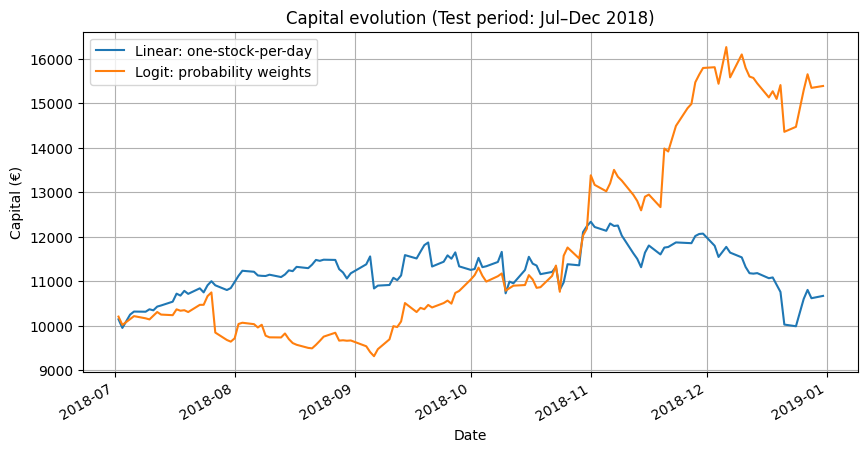

Final capital (Linear one-stock): 10666.67466229849
Final capital (Logit weights):    15387.849219431622


In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
cap_lin_one.plot(label="Linear: one-stock-per-day")
cap_logit.plot(label="Logit: probability weights")
plt.title("Capital evolution (Test period: Jul–Dec 2018)")
plt.xlabel("Date")
plt.ylabel("Capital (€)")
plt.grid(True)
plt.legend()
plt.show()

print("Final capital (Linear one-stock):", float(cap_lin_one.iloc[-1]))
print("Final capital (Logit weights):   ", float(cap_logit.iloc[-1]))


## Optional: integer-share simulation

This converts the strategy weights into **integer shares** each day at the open (full rebalance daily).


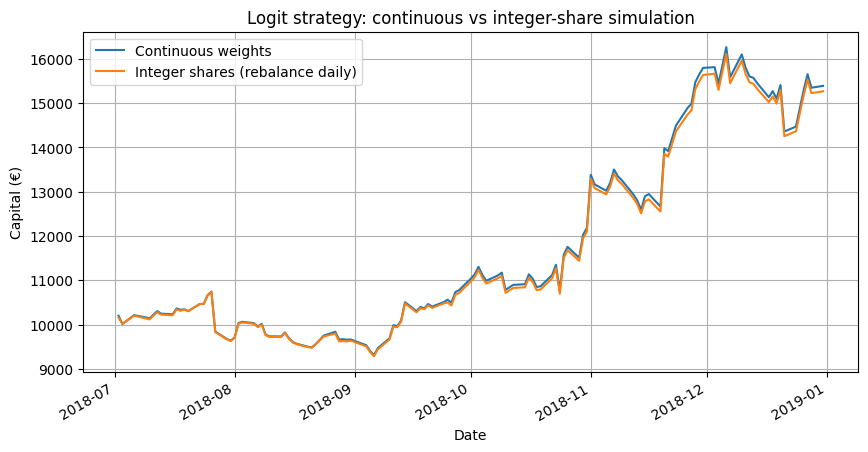

Final capital (Logit continuous): 15387.849219431622
Final capital (Logit integer):    15264.950673999989


In [18]:
# Integer shares for logit strategy (example)
shares_logit = weights_to_integer_shares(W_logit, Open.loc[test_idx2, TICKERS], C0=10000.0)
cap_logit_int = backtest_integer_shares(shares_logit, Open.loc[test_idx2, TICKERS], R.loc[test_idx2, TICKERS], C0=10000.0)

plt.figure(figsize=(10,5))
cap_logit.plot(label="Continuous weights")
cap_logit_int.plot(label="Integer shares (rebalance daily)")
plt.title("Logit strategy: continuous vs integer-share simulation")
plt.xlabel("Date")
plt.ylabel("Capital (€)")
plt.grid(True)
plt.legend()
plt.show()

print("Final capital (Logit continuous):", float(cap_logit.iloc[-1]))
print("Final capital (Logit integer):   ", float(cap_logit_int.iloc[-1]))


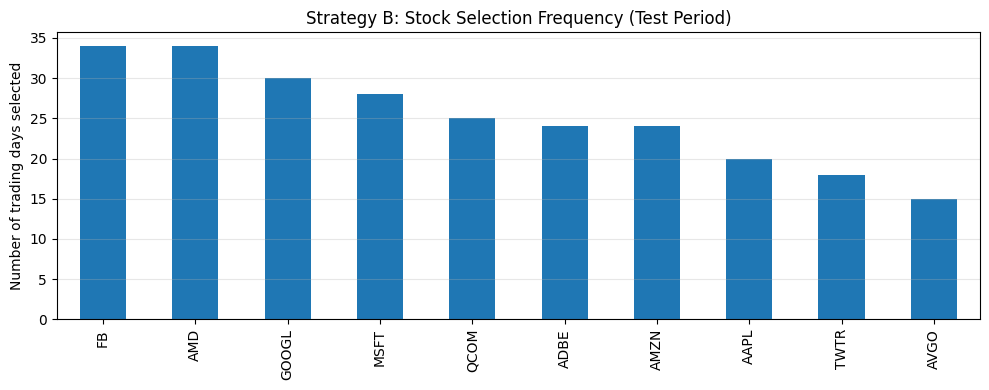

In [19]:
# Count how many days each stock has non-zero weight
selection_freq = (W_logit > 0).sum()
selection_freq = selection_freq.sort_values(ascending=False)

plt.figure(figsize=(10, 4))
selection_freq.plot(kind='bar')
plt.ylabel("Number of trading days selected")
plt.title("Strategy B: Stock Selection Frequency (Test Period)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


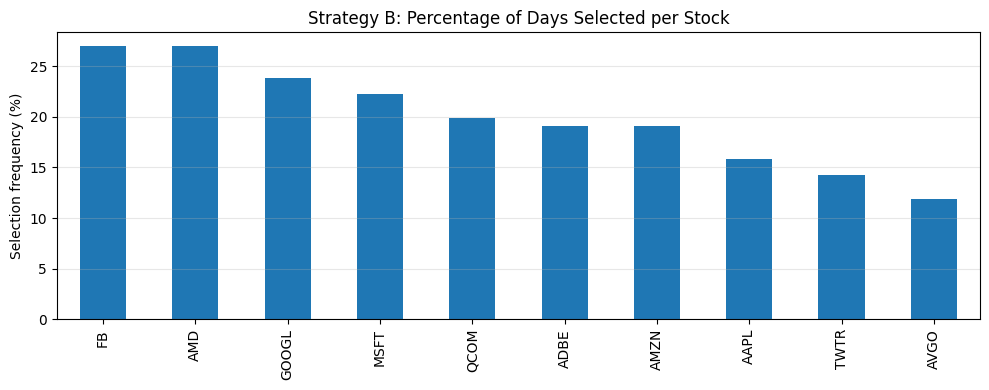

In [20]:
selection_pct = 100 * selection_freq / len(W_logit)

plt.figure(figsize=(10, 4))
selection_pct.plot(kind='bar')
plt.ylabel("Selection frequency (%)")
plt.title("Strategy B: Percentage of Days Selected per Stock")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


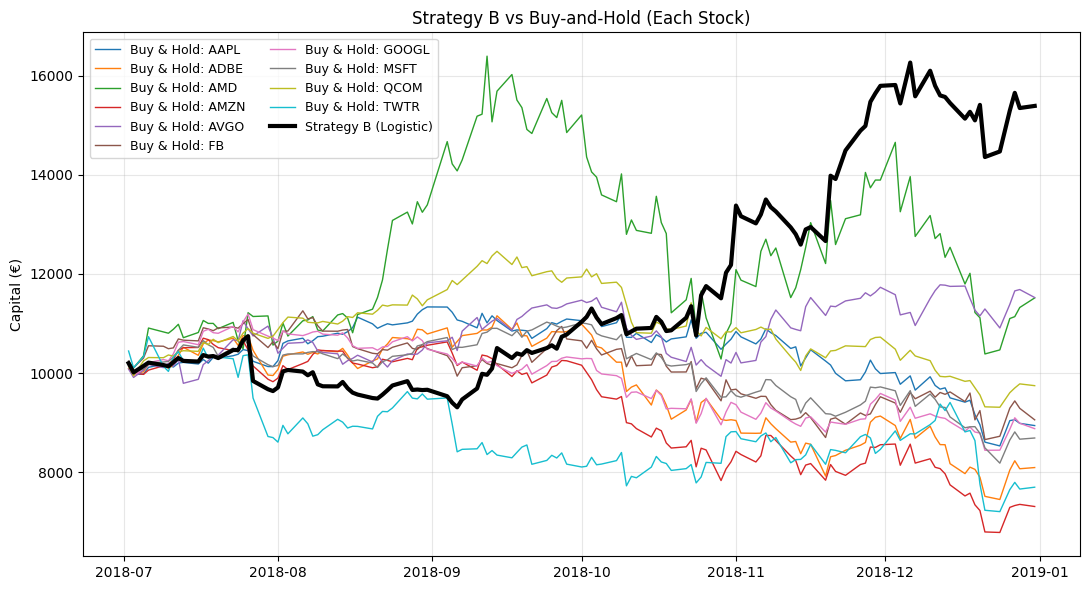

In [21]:
C0 = 10000

buy_hold_caps = {}

R_test = R.loc[TEST_START:TEST_END]

for k in TICKERS:
    bh_returns = R_test[k]
    buy_hold_caps[k] = C0 * (1 + bh_returns).cumprod()

buy_hold_df = pd.DataFrame(buy_hold_caps)


plt.figure(figsize=(11, 6))

# Buy-and-hold curves (thin, labeled)
for k in TICKERS:
    plt.plot(
        buy_hold_df.index,
        buy_hold_df[k],
        alpha=1,
        linewidth=1,
        label=f"Buy & Hold: {k}"
    )


# Strategy B curve (thick)
plt.plot(
    cap_logit.index,
    cap_logit,
    color='black',
    linewidth=3,
    label='Strategy B (Logistic)'
)


plt.legend(ncol=2, fontsize=9)
plt.ylabel("Capital (€)")
plt.title("Strategy B vs Buy-and-Hold (Each Stock)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



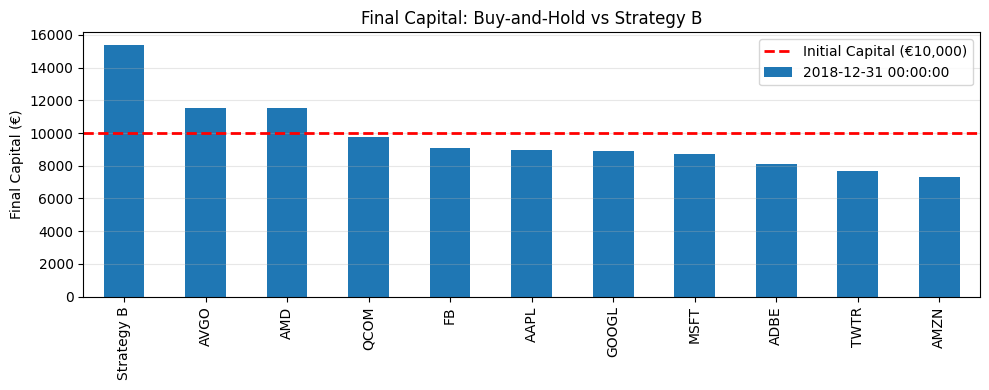

In [22]:
final_caps = buy_hold_df.iloc[-1]
final_caps['Strategy B'] = cap_logit.iloc[-1]

final_caps = final_caps.sort_values(ascending=False)

plt.figure(figsize=(10, 4))

final_caps.plot(kind='bar')

# Horizontal reference line at initial capital
plt.axhline(
    y=10000,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Initial Capital (€10,000)'
)

plt.ylabel("Final Capital (€)")
plt.title("Final Capital: Buy-and-Hold vs Strategy B")
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



In [23]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

cap_logit = backtest_weights(
    W_logit,
    R.loc[test_idx2, TICKERS],
    C0=10000.0
)

print("Final TEST capital (continuous):", float(cap_logit.iloc[-1]))


Final TEST capital (continuous): 15387.849219431622
